In [4]:
import numpy as np
import matplotlib.pyplot as plt
from utils import annotated_heatmap, analytical_policy_evaluation, epsilon_greedy_policy
from environments import CorridorEnvTerminalReward

In [5]:
env = CorridorEnvTerminalReward(n_states=10, is_slippery=False)

n_states = env.nS
n_actions = env.nA

possible_actions = np.linspace(0, env.nA-1, env.nA)

In [14]:
def collect_offline_data(env, num_episodes=500):
    dataset = []
    for _ in range(num_episodes):
        s = np.random.randint(0, env.nS)
        done = False
        while not done:
            # Behavior policy: here we just use random actions
            a = np.random.choice(env.nA) 
            [_, s_next, r, done] = env.step(s, a)[0]
            
            dataset.append({
                's': s,
                'a': a,
                'r': r,
                's_next': s_next,
                'done': done
            })
            s = s_next
    return dataset

# Generate the fixed dataset
offline_dataset = collect_offline_data(env, num_episodes=10)
print(f"Dataset size: {len(offline_dataset)} transitions")

Dataset size: 611 transitions


In [15]:
def offline_q_learning(dataset, n_states, n_actions, alpha=0.1, gamma=0.95, epochs=50):
    # Initialize Q-table
    q = [[0.0 for _ in range(n_actions)] for _ in range(n_states)]
    
    # For evaluation against analytical values (similar to your notebook)
    err = []
    optimal_pi = [[0, 0, 1]] * n_states
    v_analytical = analytical_policy_evaluation(optimal_pi, env.model, gamma=gamma)

    for epoch in range(epochs):
        # In Offline RL, we shuffle the dataset and iterate through it
        np.random.shuffle(dataset)
        
        for transition in dataset:
            s = transition['s']
            a = transition['a']
            r = transition['r']
            s_next = transition['s_next']
            done = transition['done']
            
            # Standard Q-Learning Update (Bellman Equation)
            # Notice we use max(q[s_next]) - this is the "target"
            target = r + gamma * max(q[s_next]) * (not done)
            error = target - q[s][a]
            q[s][a] += alpha * error
        
        # Calculate current Value Function for error tracking
        v_current = [max(q_row) for q_row in q]
        current_err = sum((v_analytical - v_current)**2) / n_states
        err.append(current_err)
        
    return q, err

In [16]:
# Train
q_offline, err_history = offline_q_learning(
    offline_dataset, 
    env.nS, 
    env.nA, 
    epochs=100
)

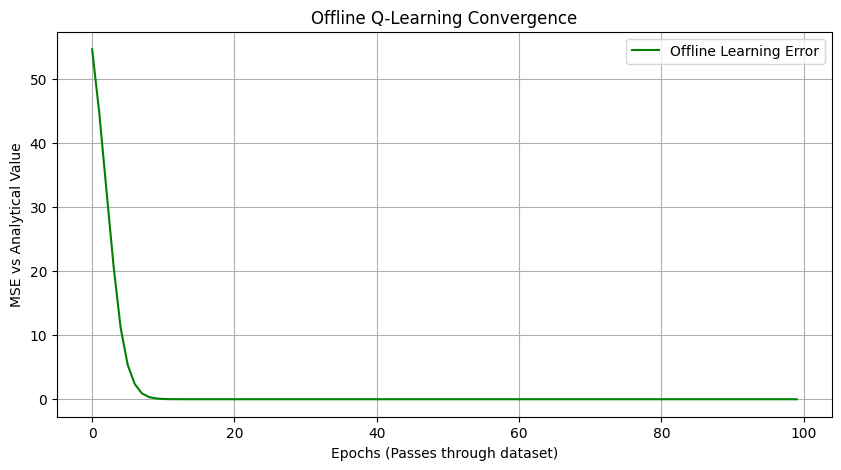

In [17]:
# Plotting the convergence
plt.figure(figsize=(10, 5))
plt.plot(err_history, color='green', label='Offline Learning Error')
plt.xlabel("Epochs (Passes through dataset)")
plt.ylabel("MSE vs Analytical Value")
plt.title("Offline Q-Learning Convergence")
plt.legend()
plt.grid(True)
plt.show()